In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, MobileNet, InceptionV3, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Class Distribution: {'glioma': 564, 'meningioma': 358, 'no_tumor': 335, 'pituitary': 438}


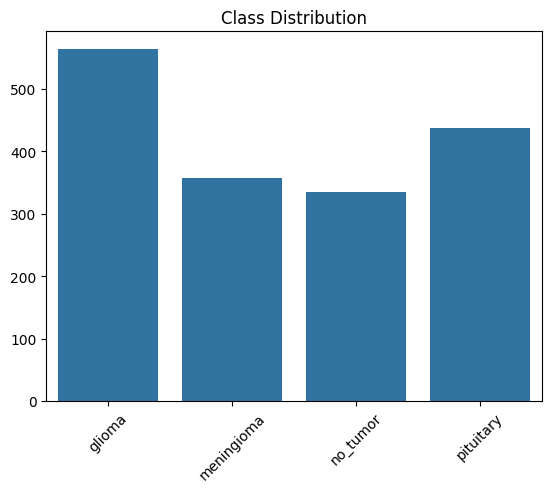

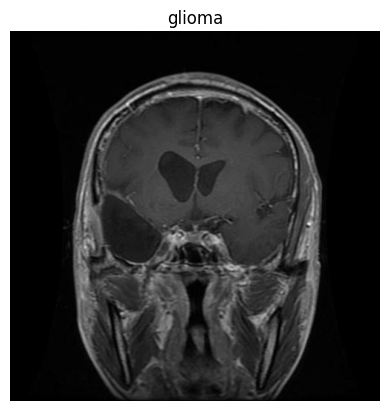

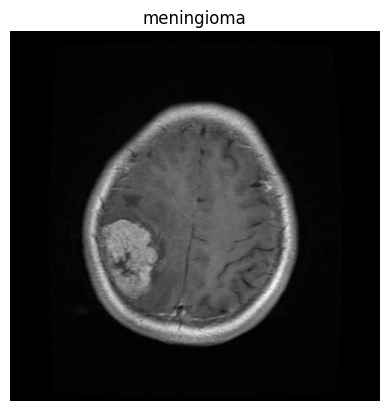

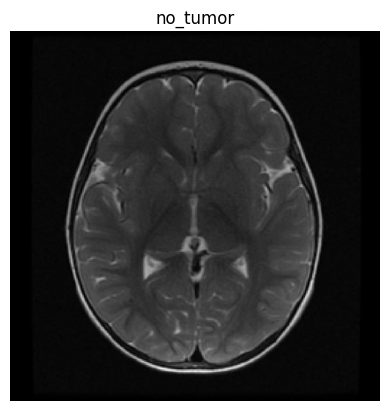

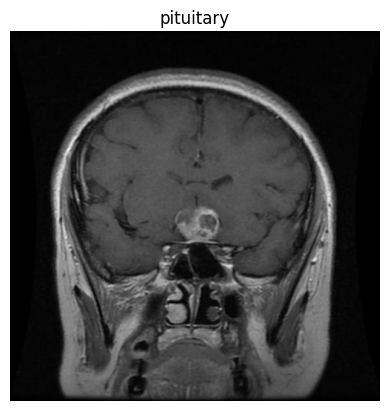

In [2]:
DATA_DIR = r"C:\Users\Varshini V\OneDrive\Documents\VS_code\venv\brain_tumour_classification\Tumour\Tumour\train"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Only keep directories (ignore files like .csv)
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print("Classes:", classes)

# Count images per class
class_counts = {}
for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(DATA_DIR, cls)))

print("Class Distribution:", class_counts)

# Plot class distribution
plt.figure()
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# Display sample images
for cls in classes[:4]:
    img_path = os.path.join(DATA_DIR, cls, os.listdir(os.path.join(DATA_DIR, cls))[0])
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    plt.show()

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

NUM_CLASSES = len(train_gen.class_indices)

Found 1358 images belonging to 4 classes.
Found 337 images belonging to 4 classes.


In [4]:
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

In [5]:
def build_transfer_model(name, input_shape, num_classes):

    if name == 'resnet':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name == 'mobilenet':
        base = MobileNet(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name == 'inception':
        base = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name == 'efficientnet':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Invalid model name")

    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    return model, base

In [6]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

In [7]:
histories = {}
models = {}

# 🔹 Train Custom CNN
cnn_model = build_cnn((224,224,3), NUM_CLASSES)
compile_model(cnn_model)

print("\nTraining Custom CNN...")
histories['cnn'] = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)
models['cnn'] = cnn_model

# 🔹 List of pretrained models
model_list = ['resnet', 'mobilenet', 'inception', 'efficientnet']

for name in model_list:
    print(f"\nTraining {name.upper()}...")
    
    tl_model, base_model = build_transfer_model(name, (224,224,3), NUM_CLASSES)
    compile_model(tl_model)

    history = tl_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=20,
        callbacks=callbacks
    )

    histories[name] = history
    models[name] = tl_model


c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Custom CNN...
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5028 - loss: 2.1803

43/43 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.5177 - loss: 1.6085 - val_accuracy: 0.2582 - val_loss: 2.6178
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5302 - loss: 1.0847 - val_accuracy: 0.2582 - val_loss: 5.0711
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 240s 6s/step - accuracy: 0.5604 - loss: 1.0551 - val_accuracy: 0.2582 - val_loss: 7.9373
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 333s 8s/step - accuracy: 0.5832 - loss: 1.0415 - val_accuracy: 0.2582 - val_loss: 6.0585
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 205s 5s/step - accuracy: 0.5803 - loss: 1.0178 - val_accuracy: 0.2641 - val_loss: 5.3185
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.6311 - loss: 0.9218 - val_accuracy: 0.2582 - val_loss: 4.6690

Training RESNET...
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.4178 - loss: 1.2763

43/43 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.4764 - loss: 1.2175 - val_accuracy: 0.2107 - val_loss: 1.4492
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.5255 - loss: 1.1176

43/43 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5545 - loss: 1.0856 - val_accuracy: 0.2136 - val_loss: 1.3880
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5724 - loss: 1.0399

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 371ms/step - accuracy: 0.8527 - loss: 0.3991 - val_accuracy: 0.7804 - val_loss: 0.5938
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8413 - loss: 0.3992

43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 382ms/step - accuracy: 0.8623 - loss: 0.3687 - val_accuracy: 0.7834 - val_loss: 0.5886
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8739 - loss: 0.3476

43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 380ms/step - accuracy: 0.8630 - loss: 0.3688 - val_accuracy: 0.8042 - val_loss: 0.5635
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 379ms/step - accuracy: 0.8726 - loss: 0.3430 - val_accuracy: 0.7923 - val_loss: 0.5702
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 367ms/step - accuracy: 0.8792 - loss: 0.3347 - val_accuracy: 0.7804 - val_loss: 0.6245
Epoch 13/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 371ms/step - accuracy: 0.8925 - loss: 0.3074 - val_accuracy: 0.7953 - val_loss: 0.5927
Epoch 14/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 367ms/step - accuracy: 0.8999 - loss: 0.2935 - val_accuracy: 0.7953 - val_loss: 0.5704
Epoch 15/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8897 - loss: 0.2773

43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 388ms/step - accuracy: 0.8925 - loss: 0.2758 - val_accuracy: 0.8160 - val_loss: 0.5523
Epoch 16/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9031 - loss: 0.3040

43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 385ms/step - accuracy: 0.9043 - loss: 0.2889 - val_accuracy: 0.8220 - val_loss: 0.5487
Epoch 17/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 372ms/step - accuracy: 0.9080 - loss: 0.2573 - val_accuracy: 0.8071 - val_loss: 0.5536
Epoch 18/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 353ms/step - accuracy: 0.8881 - loss: 0.2928 - val_accuracy: 0.8042 - val_loss: 0.5502
Epoch 19/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 353ms/step - accuracy: 0.9087 - loss: 0.2444 - val_accuracy: 0.7834 - val_loss: 0.6151
Epoch 20/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 352ms/step - accuracy: 0.9109 - loss: 0.2438 - val_accuracy: 0.8071 - val_loss: 0.5877

Training INCEPTION...
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 541ms/step - accuracy: 0.4941 - loss: 1.4796 - val_accuracy: 0.5341 - val_loss: 1.0918
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 510ms/step - accuracy: 0.6878 - loss: 0.9047 - val_accuracy: 0.6053 - val_loss: 0.9002
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 526ms/step - accuracy: 0.7467 - loss: 0

In [11]:
def evaluate_model(model, generator):
    generator.reset()

    # Get predictions
    preds = model.predict(generator, verbose=0)
    y_pred = np.argmax(preds, axis=1)

    # True labels
    y_true = generator.classes

    # Class labels
    class_labels = list(generator.class_indices.keys())

    # Classification report
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_labels,
                yticklabels=class_labels,
                cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


Evaluating CNN...

Classification Report:

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       112
  meningioma       0.00      0.00      0.00        71
    no_tumor       0.00      0.00      0.00        67
   pituitary       0.26      1.00      0.41        87

    accuracy                           0.26       337
   macro avg       0.06      0.25      0.10       337
weighted avg       0.07      0.26      0.11       337



c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

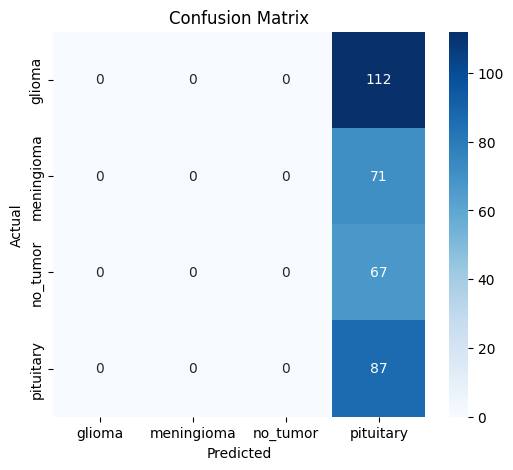


Evaluating RESNET...

Classification Report:

              precision    recall  f1-score   support

      glioma       0.31      0.38      0.34       112
  meningioma       0.23      0.15      0.18        71
    no_tumor       0.27      0.13      0.18        67
   pituitary       0.26      0.36      0.30        87

    accuracy                           0.28       337
   macro avg       0.27      0.26      0.25       337
weighted avg       0.27      0.28      0.26       337



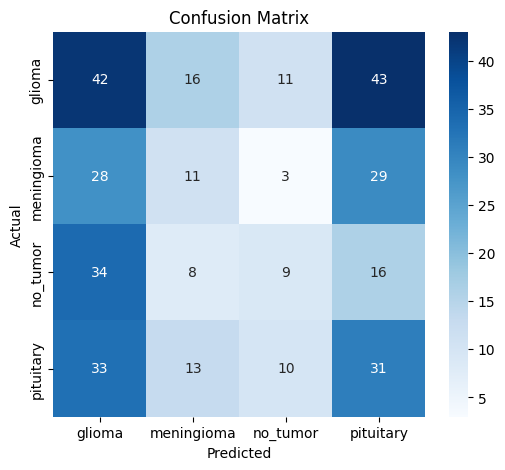


Evaluating MOBILENET...

Classification Report:

              precision    recall  f1-score   support

      glioma       0.34      0.28      0.30       112
  meningioma       0.18      0.24      0.21        71
    no_tumor       0.24      0.22      0.23        67
   pituitary       0.23      0.24      0.24        87

    accuracy                           0.25       337
   macro avg       0.25      0.25      0.25       337
weighted avg       0.26      0.25      0.25       337



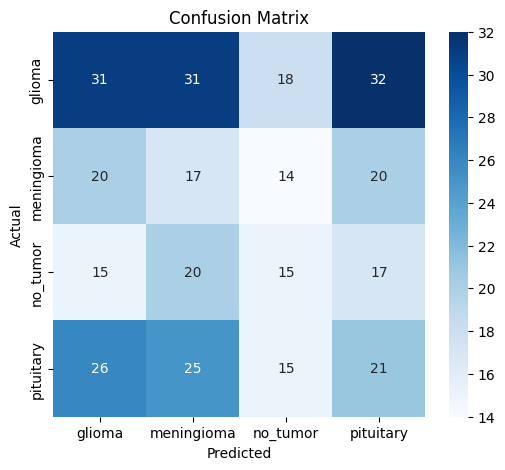


Evaluating INCEPTION...

Classification Report:

              precision    recall  f1-score   support

      glioma       0.15      0.06      0.09       112
  meningioma       0.22      0.56      0.31        71
    no_tumor       0.19      0.13      0.16        67
   pituitary       0.32      0.21      0.25        87

    accuracy                           0.22       337
   macro avg       0.22      0.24      0.20       337
weighted avg       0.21      0.22      0.19       337



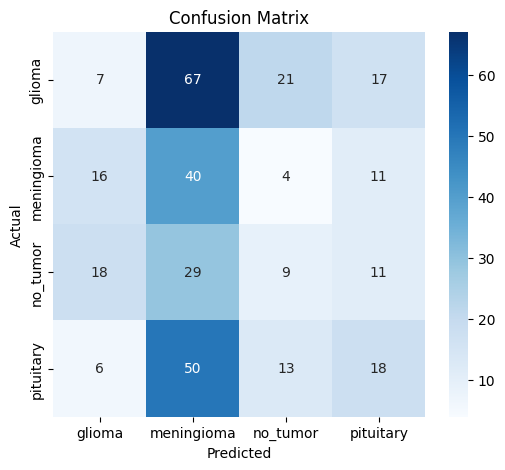


Evaluating EFFICIENTNET...

Classification Report:

              precision    recall  f1-score   support

      glioma       0.33      1.00      0.50       112
  meningioma       0.00      0.00      0.00        71
    no_tumor       0.00      0.00      0.00        67
   pituitary       0.00      0.00      0.00        87

    accuracy                           0.33       337
   macro avg       0.08      0.25      0.12       337
weighted avg       0.11      0.33      0.17       337



c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

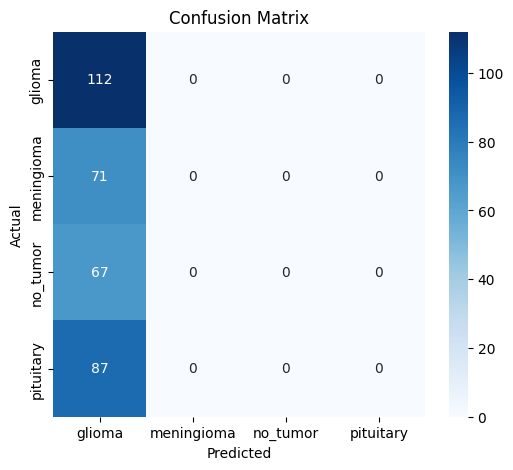

In [12]:
for name, model in models.items():
    print(f"\nEvaluating {name.upper()}...\n")
    evaluate_model(model, val_gen)

In [13]:
def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Accuracy plot (left)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss plot (right)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{title} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

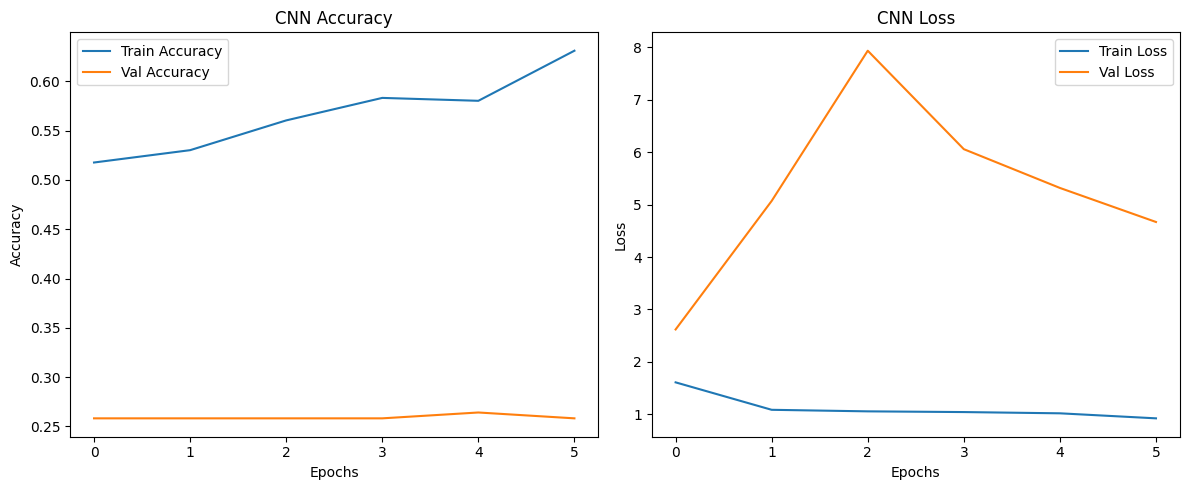

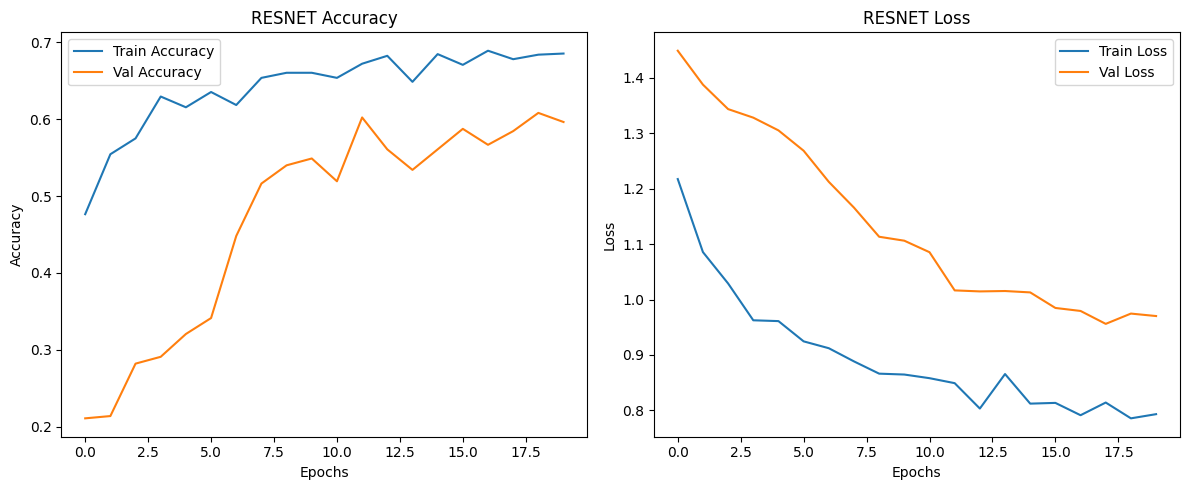

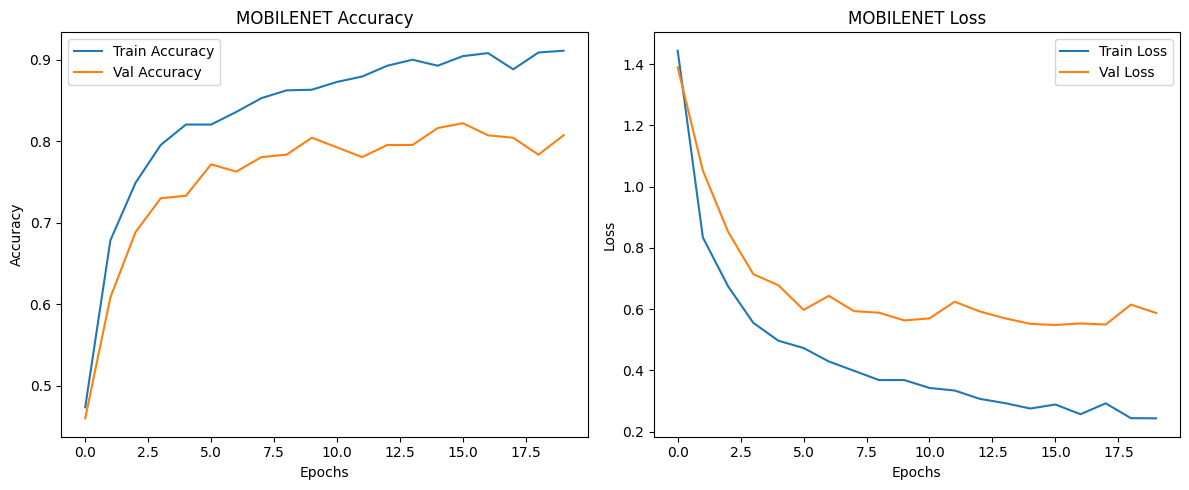

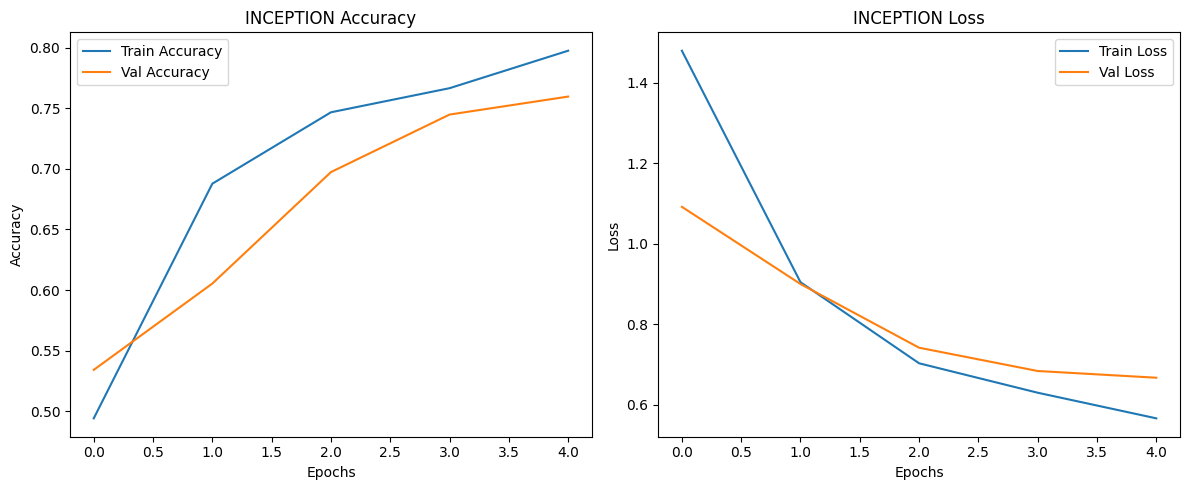

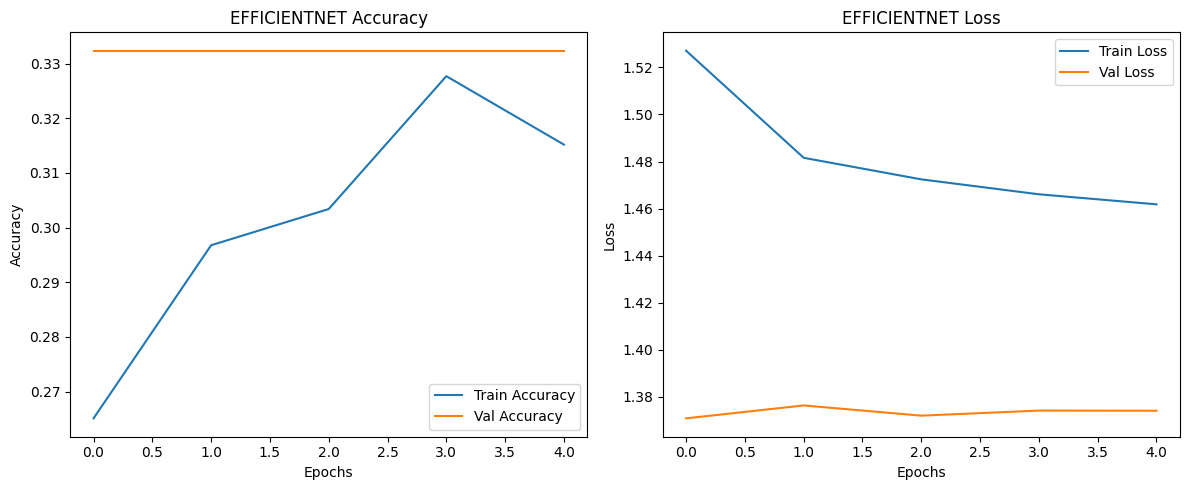

In [14]:
plot_history(histories['cnn'], "CNN")

for name in ['resnet', 'mobilenet', 'inception', 'efficientnet']:
    plot_history(histories[name], name.upper())